*Leekhith Nunna*

*BL.EN.U4AIE23060*

Set up the environment

In [1]:
!pip install gymnasium

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Version of `gymnasium`

In [4]:
import gymnasium as gym
print("gymnasium version:", gym.__version__)

gymnasium version: 1.3.0


Create the environment

In [5]:
import gymnasium as gym
env = gym.make("CartPole-v1")

print("Environment object:", env)
print("Type:", type(env))
print("Environment ID:", env.spec.id)
print("Max episode steps allowed:", env.spec.max_episode_steps)
print("Reward threshold (considered 'solved'):", env.spec.reward_threshold)

Environment object: <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
Type: <class 'gymnasium.wrappers.common.TimeLimit'>
Environment ID: CartPole-v1
Max episode steps allowed: 500
Reward threshold (considered 'solved'): 475.0


Reset

In [6]:
obs, info = env.reset(seed=42)

print("Initial observation:", obs)
print("Type:", type(obs))
print("Shape:", obs.shape)
print("Info dict:", info)

labels = ["Cart position", "Cart velocity", "Pole angle", "Pole angular velocity"]
for label, value in zip(labels, obs):
    print(f"{label}: {value:.4f}")

Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Type: <class 'numpy.ndarray'>
Shape: (4,)
Info dict: {}
Cart position: 0.0274
Cart velocity: -0.0061
Pole angle: 0.0359
Pole angular velocity: 0.0197


Initial observation — look at what it actually contains

In [7]:
print("Raw observation array:", obs)

print("Index 0 (Cart Position):        ", obs[0], " | valid range: -4.8 to 4.8")
print("Index 1 (Cart Velocity):        ", obs[1], " | valid range: -inf to inf")
print("Index 2 (Pole Angle, radians):  ", obs[2], " | valid range: -0.418 to 0.418")
print("Index 3 (Pole Angular Velocity):", obs[3], " | valid range: -inf to inf")

Raw observation array: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Index 0 (Cart Position):         0.027395604  | valid range: -4.8 to 4.8
Index 1 (Cart Velocity):         -0.006112156  | valid range: -inf to inf
Index 2 (Pole Angle, radians):   0.035859793  | valid range: -0.418 to 0.418
Index 3 (Pole Angular Velocity): 0.019736802  | valid range: -inf to inf


Sample one action

In [8]:
action = env.action_space.sample()

print("Action space:", env.action_space)
print("Sampled action:", action)
print("Type:", type(action))
print("Meaning:", "Push cart LEFT" if action == 0 else "Push cart RIGHT")

Action space: Discrete(2)
Sampled action: 0
Type: <class 'numpy.int64'>
Meaning: Push cart LEFT


Steps

In [9]:
action = env.action_space.sample()
print("Action taken:", action)

new_obs, reward, terminated, truncated, info = env.step(action)

print("New observation:", new_obs)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Action taken: 1
New observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Reward: 1.0
Terminated: False
Truncated: False
Info: {}


*Before vs after* steps

In [12]:
print("=== BEFORE step ===")
print("Observation:", obs)

print("=== Action taken:", action, "===")

print("=== AFTER step ===")
print("New observation:", new_obs)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

print("=== What changed (new_obs - obs) ===")
print(new_obs - obs)

=== BEFORE step ===
Observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
=== Action taken: 1 ===
=== AFTER step ===
New observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Reward: 1.0
Terminated: False
Truncated: False
Info: {}
=== What changed (new_obs - obs) ===
[-1.2224168e-04  1.9458982e-01  3.9473549e-04 -2.8115657e-01]


close cartpole env

In [14]:
print("Before close - env is active:", env)
env.close()
print("Environment closed.")

Before close - env is active: <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
Environment closed.


Exploration steps environments 

1. CartPole-v1

In [16]:
import gymnasium as gym

env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Max episode steps:", env.spec.max_episode_steps)
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Max episode steps: 500


2. MountainCar-v0

In [17]:
import gymnasium as gym

env = gym.make("MountainCar-v0")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Max episode steps:", env.spec.max_episode_steps)
env.close()

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Max episode steps: 200


3. FrozenLake-v1

In [18]:
import gymnasium as gym

env = gym.make("FrozenLake-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Max episode steps:", env.spec.max_episode_steps)
env.close()

Observation space: Discrete(16)
Action space: Discrete(4)
Max episode steps: 100


4. Taxi-v4

In [19]:
import gymnasium as gym

env = gym.make("Taxi-v4")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Max episode steps:", env.spec.max_episode_steps)
env.close()

Observation space: Discrete(500)
Action space: Discrete(6)
Max episode steps: 200


Create each environment

In [4]:
import gymnasium as gym

env1 = gym.make("CartPole-v1")
print("env1:", env1)
env2 = gym.make("MountainCar-v0")
print("env2:", env2)
env3 = gym.make("FrozenLake-v1")
print("env3:", env3)
env4 = gym.make("Taxi-v4")
print("env4:", env4)

env1: <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
env2: <TimeLimit<OrderEnforcing<PassiveEnvChecker<MountainCarEnv<MountainCar-v0>>>>>
env3: <TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>
env4: <TimeLimit<OrderEnforcing<PassiveEnvChecker<TaxiEnv<Taxi-v4>>>>>


Observation Spaces

In [5]:
print("CartPole-v1 observation space:", env1.observation_space)
print("Type:", type(env1.observation_space).__name__)

print("MountainCar-v0 observation space:", env2.observation_space)
print("Type:", type(env2.observation_space).__name__)

print("FrozenLake-v1 observation space:", env3.observation_space)
print("Type:", type(env3.observation_space).__name__)

print("Taxi-v4 observation space:", env4.observation_space)
print("Type:", type(env4.observation_space).__name__)

CartPole-v1 observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Type: Box
MountainCar-v0 observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Type: Box
FrozenLake-v1 observation space: Discrete(16)
Type: Discrete
Taxi-v4 observation space: Discrete(500)
Type: Discrete


Action Space

In [6]:
print("CartPole-v1 action space:", env1.action_space)
print("Type:", type(env1.action_space).__name__)

print("MountainCar-v0 action space:", env2.action_space)
print("Type:", type(env2.action_space).__name__)

print("FrozenLake-v1 action space:", env3.action_space)
print("Type:", type(env3.action_space).__name__)

print("Taxi-v4 action space:", env4.action_space)
print("Type:", type(env4.action_space).__name__)

CartPole-v1 action space: Discrete(2)
Type: Discrete
MountainCar-v0 action space: Discrete(3)
Type: Discrete
FrozenLake-v1 action space: Discrete(4)
Type: Discrete
Taxi-v4 action space: Discrete(6)
Type: Discrete


CartPole-v1 max_episode_steps: 500
MountainCar-v0 max_episode_steps: 200
FrozenLake-v1 max_episode_steps: 100
Taxi-v4 max_episode_steps: 200


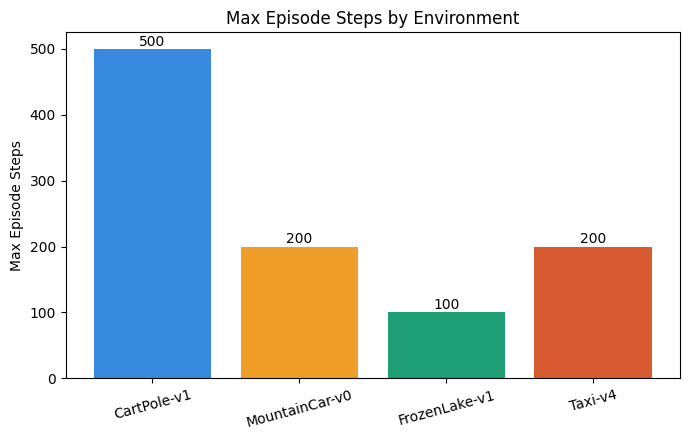

In [7]:
import gymnasium as gym
import matplotlib.pyplot as plt

env1 = gym.make("CartPole-v1")
env2 = gym.make("MountainCar-v0")
env3 = gym.make("FrozenLake-v1")
env4 = gym.make("Taxi-v4")

print("CartPole-v1 max_episode_steps:", env1.spec.max_episode_steps)
print("MountainCar-v0 max_episode_steps:", env2.spec.max_episode_steps)
print("FrozenLake-v1 max_episode_steps:", env3.spec.max_episode_steps)
print("Taxi-v4 max_episode_steps:", env4.spec.max_episode_steps)

env_names = ["CartPole-v1", "MountainCar-v0", "FrozenLake-v1", "Taxi-v4"]
max_steps = [
    env1.spec.max_episode_steps,
    env2.spec.max_episode_steps,
    env3.spec.max_episode_steps,
    env4.spec.max_episode_steps,
]

env1.close()
env2.close()
env3.close()
env4.close()

plt.figure(figsize=(7, 4.5))
bars = plt.bar(env_names, max_steps, color=["#378ADD", "#EF9F27", "#1D9E75", "#D85A30"])
plt.title("Max Episode Steps by Environment")
plt.ylabel("Max Episode Steps")
plt.xticks(rotation=15)
for bar, val in zip(bars, max_steps):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5, str(val), ha="center")
plt.tight_layout()
plt.savefig("max_episode_steps.png", dpi=150)
plt.show()

Inspecting environments: 100%|██████████| 4/4 [00:00<00:00, 135.27it/s]


Environment     Obs Space                     Action Space   Max Steps 
-----------------------------------------------------------------------
CartPole-v1     Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)Discrete(2)    500       
MountainCar-v0  Box([-1.2  -0.07], [0.6  0.07], (2,), float32)Discrete(3)    200       
FrozenLake-v1   Discrete(16)                  Discrete(4)    100       
Taxi-v4         Discrete(500)                 Discrete(6)    200       


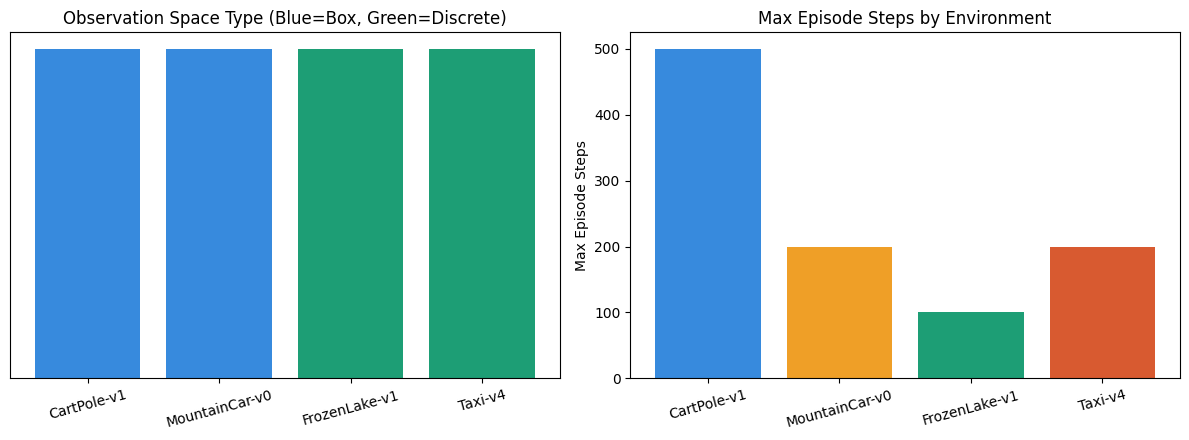

In [8]:
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm import tqdm

env_names = ["CartPole-v1", "MountainCar-v0", "FrozenLake-v1", "Taxi-v4"]

obs_spaces = []
action_spaces = []
max_steps_list = []

for name in tqdm(env_names, desc="Inspecting environments"):
    env = gym.make(name)
    obs_spaces.append(env.observation_space)
    action_spaces.append(env.action_space)
    max_steps_list.append(env.spec.max_episode_steps)
    env.close()

print(f"{'Environment':<16}{'Obs Space':<30}{'Action Space':<15}{'Max Steps':<10}")
print("-" * 71)
for name, obs, act, steps in zip(env_names, obs_spaces, action_spaces, max_steps_list):
    print(f"{name:<16}{str(obs):<30}{str(act):<15}{steps:<10}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

obs_types = [type(s).__name__ for s in obs_spaces]
colors = ["#378ADD" if t == "Box" else "#1D9E75" for t in obs_types]
axes[0].bar(env_names, [1]*len(env_names), color=colors)
axes[0].set_title("Observation Space Type (Blue=Box, Green=Discrete)")
axes[0].set_yticks([])
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(env_names, max_steps_list, color=["#378ADD", "#EF9F27", "#1D9E75", "#D85A30"])
axes[1].set_title("Max Episode Steps by Environment")
axes[1].set_ylabel("Max Episode Steps")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("env_loop_comparison.png", dpi=150)
plt.show()

**Building an random Agent**

CartPole-v1: 100%|██████████| 50/50 [00:00<00:00, 671.92it/s]



=== CartPole-v1: Random Agent over 50 episodes ===
Average reward: 21.82
Std reward: 10.05
Min / Max reward: 9.0 / 51.0
Episodes terminated: 50, truncated: 0


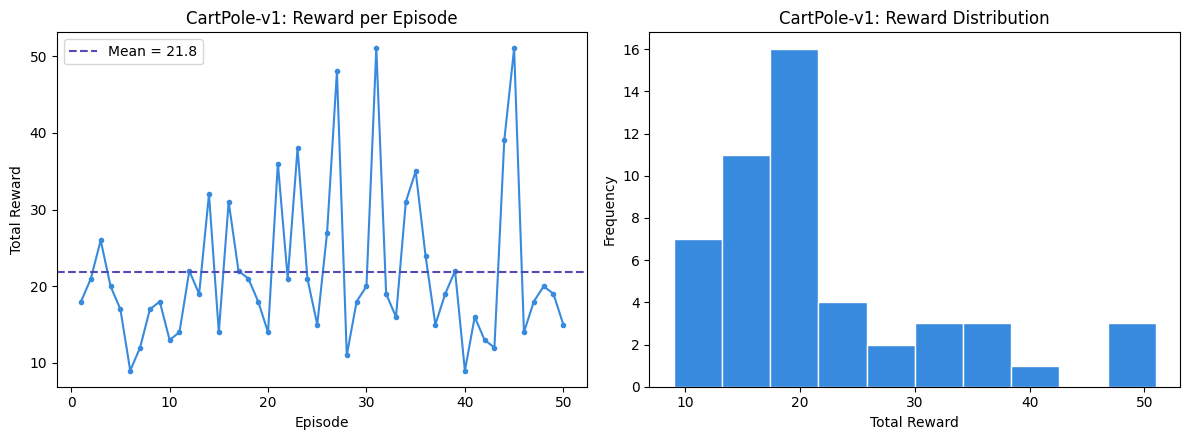

Plot saved as cartpole_v1_random_agent.png


MountainCar-v0: 100%|██████████| 50/50 [00:01<00:00, 48.71it/s]



=== MountainCar-v0: Random Agent over 50 episodes ===
Average reward: -200.00
Std reward: 0.00
Min / Max reward: -200.0 / -200.0
Episodes terminated: 0, truncated: 50


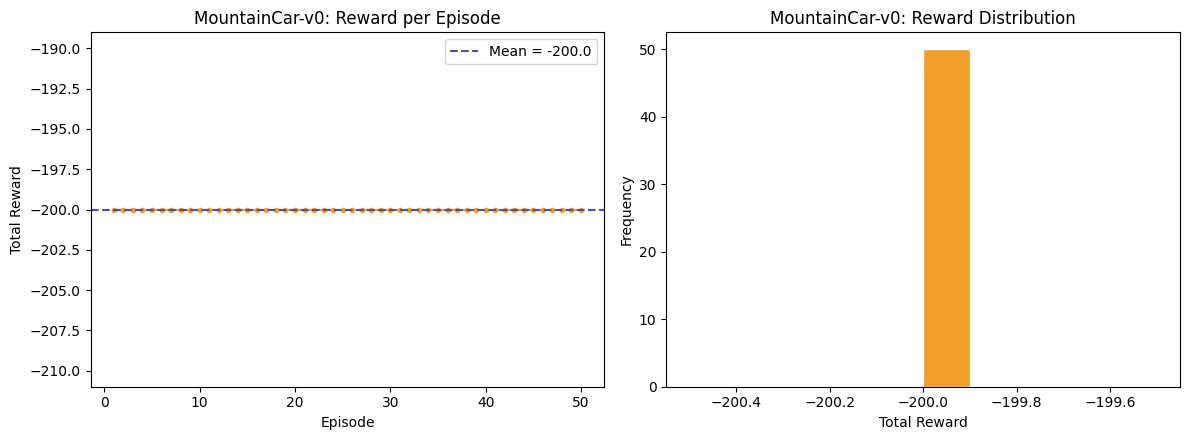

Plot saved as mountaincar_v0_random_agent.png


FrozenLake-v1: 100%|██████████| 50/50 [00:00<00:00, 535.69it/s]


=== FrozenLake-v1: Random Agent over 50 episodes ===
Average reward: 0.00
Std reward: 0.00
Min / Max reward: 0.0 / 0.0
Episodes terminated: 50, truncated: 0


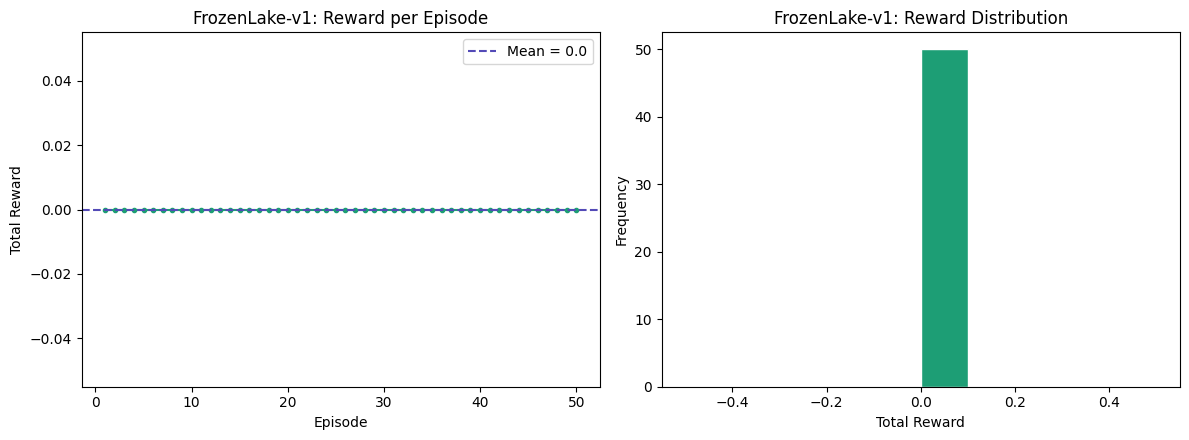

Plot saved as frozenlake_v1_random_agent.png


Taxi-v4: 100%|██████████| 50/50 [00:01<00:00, 45.19it/s]



=== Taxi-v4: Random Agent over 50 episodes ===
Average reward: -745.44
Std reward: 133.59
Min / Max reward: -938.0 / -98.0
Episodes terminated: 6, truncated: 44


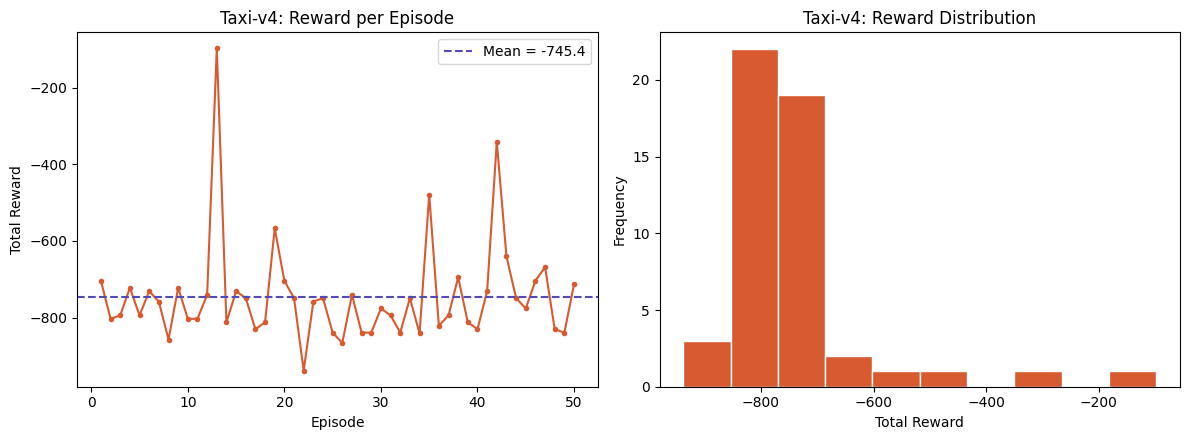

Plot saved as taxi_v4_random_agent.png


In [12]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def run_random_agent(env_name, episodes=50, seed=42):
    env = gym.make(env_name)
    rewards, steps_list = [], []
    terminated_count = truncated_count = 0
    for ep in tqdm(range(episodes), desc=f"{env_name}"):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        total_reward, steps = 0.0, 0
        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        rewards.append(total_reward)
        steps_list.append(steps)
        terminated_count += int(terminated)
        truncated_count += int(truncated)
    env.close()
    return rewards, steps_list, terminated_count, truncated_count

colors = {
    "CartPole-v1": "#378ADD",
    "MountainCar-v0": "#EF9F27",
    "FrozenLake-v1": "#1D9E75",
    "Taxi-v4": "#D85A30",
}

for name in ["CartPole-v1", "MountainCar-v0", "FrozenLake-v1", "Taxi-v4"]:
    rewards, steps_list, term_count, trunc_count = run_random_agent(name, episodes=50)

    print(f"\n=== {name}: Random Agent over 50 episodes ===")
    print(f"Average reward: {np.mean(rewards):.2f}")
    print(f"Std reward: {np.std(rewards):.2f}")
    print(f"Min / Max reward: {np.min(rewards):.1f} / {np.max(rewards):.1f}")
    print(f"Episodes terminated: {term_count}, truncated: {trunc_count}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(range(1, len(rewards) + 1), rewards, color=colors[name], marker="o", markersize=3)
    axes[0].axhline(np.mean(rewards), color="#534AB7", linestyle="--", label=f"Mean = {np.mean(rewards):.1f}")
    axes[0].set_title(f"{name}: Reward per Episode")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Total Reward")
    axes[0].legend()

    axes[1].hist(rewards, bins=10, color=colors[name], edgecolor="white")
    axes[1].set_title(f"{name}: Reward Distribution")
    axes[1].set_xlabel("Total Reward")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    fname = f"{name.replace('-', '_').lower()}_random_agent.png"
    plt.savefig(fname, dpi=150)
    plt.show()      # display the plot
    plt.close(fig)
    print(f"Plot saved as {fname}")

In [16]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Environment": "CartPole-v1",
        "Obs Space": "Box(4,) continuous",
        "Action Space": "Discrete(2)",
        "Reward Type": "Dense (+1/step)",
        "Stochastic?": "No",
        "Max Steps": 500,
    },
    {
        "Environment": "MountainCar-v0",
        "Obs Space": "Box(2,) continuous",
        "Action Space": "Discrete(3)",
        "Reward Type": "Dense but sparse goal (-1/step)",
        "Stochastic?": "No",
        "Max Steps": 200,
    },
    {
        "Environment": "FrozenLake-v1",
        "Obs Space": "Discrete(16)",
        "Action Space": "Discrete(4)",
        "Reward Type": "Sparse (0 / +1 at goal)",
        "Stochastic?": "Yes (slippery)",
        "Max Steps": 100,
    },
    {
        "Environment": "Taxi-v4",
        "Obs Space": "Discrete(500)",
        "Action Space": "Discrete(6)",
        "Reward Type": "Dense w/ penalties (-1, -10, +20)",
        "Stochastic?": "No",
        "Max Steps": 200,
    },
])

print(comparison.to_markdown(index=False))

Environment     Obs Space           Action Space  Max Steps  Reward Type         Avg Reward  Terminated  Truncated  
--------------------------------------------------------------------------------------------------------------------
CartPole-v1     Box(4,) continuous  Discrete(2)   500        Dense (+1/step)     21.82       50          0          
MountainCar-v0  Box(2,) continuous  Discrete(3)   200        Dense, sparse goal  -200.0      0           50         
FrozenLake-v1   Discrete(16)        Discrete(4)   100        Sparse (0/+1 goal)  0.0         50          0          
Taxi-v4         Discrete(500)       Discrete(6)   200        Dense w/ penalties  -745.44     6           44         


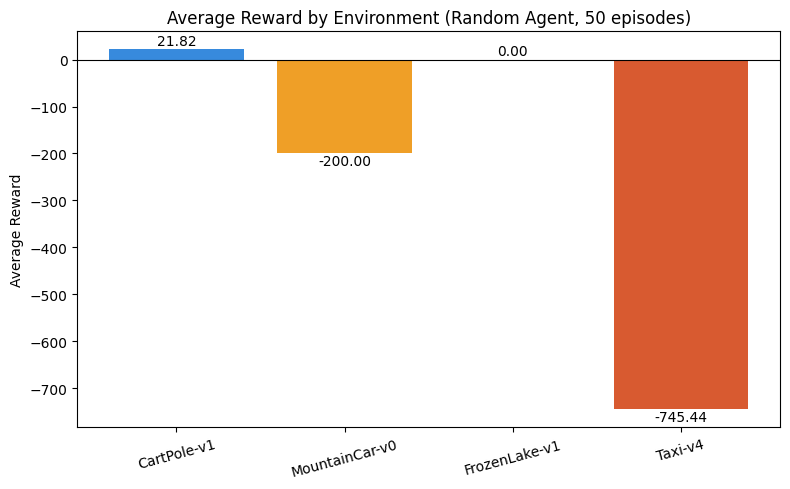

In [19]:
import pandas as pd
import numpy as np

comparison = pd.DataFrame([
    {"Environment": "CartPole-v1", "Obs Space": "Box(4,) continuous", "Action Space": "Discrete(2)",
     "Max Steps": 500, "Reward Type": "Dense (+1/step)", "Avg Reward": 21.82, "Terminated": 50, "Truncated": 0},
    {"Environment": "MountainCar-v0", "Obs Space": "Box(2,) continuous", "Action Space": "Discrete(3)",
     "Max Steps": 200, "Reward Type": "Dense, sparse goal", "Avg Reward": -200.0, "Terminated": 0, "Truncated": 50},
    {"Environment": "FrozenLake-v1", "Obs Space": "Discrete(16)", "Action Space": "Discrete(4)",
     "Max Steps": 100, "Reward Type": "Sparse (0/+1 goal)", "Avg Reward": 0.0, "Terminated": 50, "Truncated": 0},
    {"Environment": "Taxi-v4", "Obs Space": "Discrete(500)", "Action Space": "Discrete(6)",
     "Max Steps": 200, "Reward Type": "Dense w/ penalties", "Avg Reward": -745.44, "Terminated": 6, "Truncated": 44},
])

arr = comparison.astype(str).to_numpy()
headers = comparison.columns.tolist()
col_widths = [max(len(str(x)) for x in [h] + list(arr[:, i])) + 2 for i, h in enumerate(headers)]

row_fmt = "".join(f"{{:<{w}}}" for w in col_widths)
print(row_fmt.format(*headers))
print("-" * sum(col_widths))
for row in arr:
    print(row_fmt.format(*row))


import matplotlib.pyplot as plt

env_names = ["CartPole-v1", "MountainCar-v0", "FrozenLake-v1", "Taxi-v4"]
avg_rewards = [21.82, -200.0, 0.0, -745.44]
colors = ["#378ADD", "#EF9F27", "#1D9E75", "#D85A30"]

plt.figure(figsize=(8, 5))
bars = plt.bar(env_names, avg_rewards, color=colors)

for bar, val in zip(bars, avg_rewards):
    y_pos = val + (10 if val >= 0 else -25)
    plt.text(bar.get_x() + bar.get_width()/2, y_pos, f"{val:.2f}", ha="center", fontsize=10)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Reward by Environment (Random Agent, 50 episodes)")
plt.ylabel("Average Reward")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("avg_reward_comparison.png", dpi=150)
plt.show()